# Group 2

In [78]:
# Import the necessary Libraries
import pandas as pd
import numpy as np
import json
import os
import random
import shutil
import cv2
import os
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
from PIL import Image
import matplotlib.pyplot as plt

import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")

# Data and Image Preprocessing - Clifford

In [79]:
# Define photos directory
photos_dir='./Yelp Photos/photos'

In [80]:
# Load the photos JSON file
photos_df = pd.read_json("./Yelp Photos/photos.json", lines=True)

In [81]:
# Load the business JSON file
business_df = pd.read_json("./Yelp JSON/yelp_dataset/yelp_academic_dataset_business.json", lines=True)

In [82]:
# Check the head of the photos dataframe
photos_df.head()

,photo_id,business_id,caption,label
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food


In [83]:
# Check the info of the photos dataframe
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


In [84]:
# Check the labels of the photos
photos_df['label'].unique()

array(['inside', 'outside', 'drink', 'food', 'menu'], dtype=object)

In [85]:
# Check the head of the business dataframe
business_df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


## Labels Distribution

In [86]:
# Function for label distribution
def plot_label_distribution(df):
    plt.figure(figsize=(10, 6))
    palette = plt.get_cmap('Set2').colors
    ax = sns.countplot(
        data=df,
        x='label',
        order=df['label'].value_counts().index,
        palette=palette
    )
    plt.title("Image Count per Label")
    plt.xlabel("Label")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)

    # Add count labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 0.3,
            int(height),
            ha="center"
        )

    plt.tight_layout()
    plt.show()

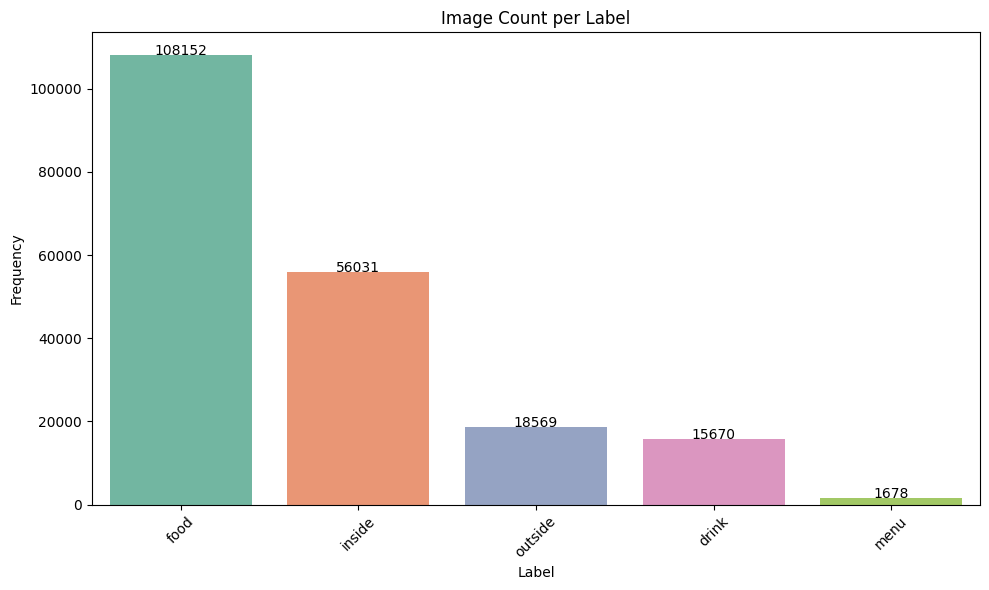

In [87]:
# Plot the distribution
plot_label_distribution(photos_df)

In [88]:
# Photo labels count
photos_df.groupby('label')['photo_id'].count()

label
drink       15670
food       108152
inside      56031
menu         1678
outside     18569
Name: photo_id, dtype: int64

## Balance the Dataset by Undersampling

In [89]:
# Function to balance dataset
def balanced_sample(df, label_col='label'):
    # Find the minimum count across all labels
    min_count = df[label_col].value_counts().min()
    print(f" Sampling {min_count} images per label to ensure class balance.")

    # Perform undersampling for each class
    balanced_df = df.groupby(label_col).apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)

    print(f" Balanced DataFrame created with {len(balanced_df)} rows across {df[label_col].nunique()} classes.")
    return balanced_df

# Usage
photos_df_balanced = balanced_sample(photos_df)

 Sampling 1678 images per label to ensure class balance.
 Balanced DataFrame created with 8390 rows across 5 classes.


In [90]:
photos_df_balanced.to_csv('balanced_photos_df.csv')

In [91]:
#  Merge the two dataframes on 'business_id'
df = photos_df_balanced.merge(business_df, on="business_id", how="left")

In [92]:
df.shape

(8390, 17)

In [93]:
df.head()

,photo_id,business_id,caption,label,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Chro0cjWAFLtdv-pmGSB6Q,oBNrLz4EDhiscSlbOl8uAw,Bacon Infused Bloody Mary,drink,Ruby Slipper - New Orleans,200 Magazine St,New Orleans,LA,70130,29.951025,-90.067394,4.5,5193,1,"{'NoiseLevel': ''loud'', 'Caters': 'False', 'B...","Restaurants, American (Traditional), American ...","{'Monday': '0:0-0:0', 'Tuesday': '7:30-14:0', ..."
1,BD8F_GP5TiNCiajFVPqZOA,SV04xdj87VOEa4GJ2dZm_g,,drink,You Cha Cafe,1601 N Kings Hwy,Cherry Hill,NJ,08034,39.916220,-75.007034,4.5,44,1,"{'RestaurantsDelivery': 'True', 'WheelchairAcc...","Bubble Tea, Food, Restaurants, Cafes","{'Monday': '0:0-0:0', 'Tuesday': '11:30-18:0',..."
2,Wo16TBTZHfapyV2n_KbCTQ,EM0jUQn-SEnttG8hf-Eq6A,Huckleberry lemon drop at the bar,drink,Bardenay Restaurant & Distillery - Eagle,155 E Riverside St,Eagle,ID,83616,43.686635,-116.352242,4.0,351,1,"{'GoodForKids': 'True', 'BusinessParking': '{'...","Food, Cocktail Bars, Nightlife, Distilleries, ...","{'Monday': '0:0-0:0', 'Tuesday': '11:0-21:0', ..."
3,1gBfJMbZtrgcqqvgDaYWYA,5Z_KrsEQsPE0ibKwhYn3ZQ,,drink,Signature Grill,3800 W Starr Pass Blvd,Tucson,AZ,85745,32.215561,-111.050749,3.5,105,1,"{'RestaurantsGoodForGroups': 'True', 'OutdoorS...","American (New), Restaurants, Southern, Breakfa...","{'Monday': '17:0-22:0', 'Tuesday': '17:0-22:0'..."
4,Qy65xh-hrmPTb2k_-6uZnA,yd5CI-2fASWsrA92dUR1ZA,,drink,Brewforia Beer Market,"3030 E Overland Rd, Ste 100",Meridian,ID,83642,43.590798,-116.356710,4.0,52,0,"{'BusinessParking': '{'garage': False, 'street...","American (New), Beer, Wine & Spirits, Restaura...","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'..."


## Sample Images by Labels

In [94]:
# Function to show sample images
def show_sample_images(df, img_dir, num_samples=2):
    labels = df['label'].unique()
    n_labels = len(labels)
    fig, axes = plt.subplots(n_labels, num_samples, figsize=(15, 2 * n_labels))

    for i, label in enumerate(labels):
        sample_ids = df[df['label'] == label]['photo_id'].sample(num_samples, random_state=42).tolist()
        for j, photo_id in enumerate(sample_ids):
            img_path = os.path.join(img_dir, f"{photo_id}.jpg")
            try:
                img = Image.open(img_path)
                ax = axes[i, j] if n_labels > 1 else axes[j]
                ax.imshow(img)
                ax.axis('off')
                if j == 0:
                    ax.set_ylabel(label, fontsize=14)
            except Exception:
                # Optionally, you can clear the axis if image loading fails
                ax = axes[i, j] if n_labels > 1 else axes[j]
                ax.axis('off')
    plt.tight_layout()
    plt.show()

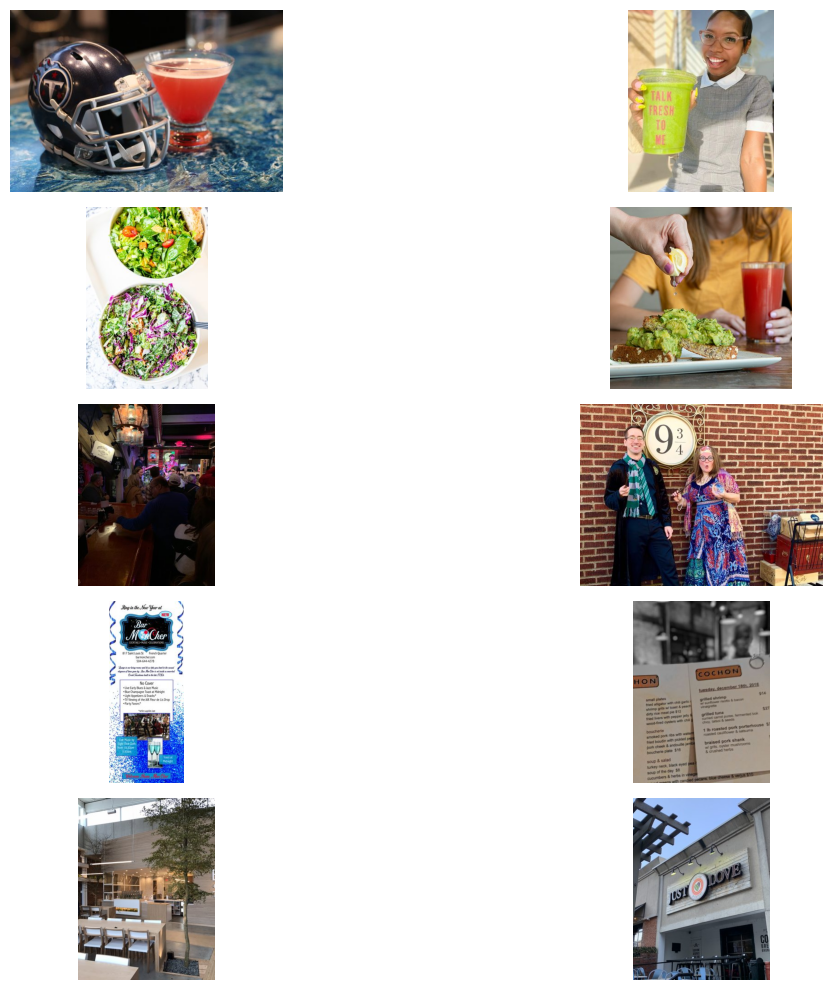

In [95]:
# Show samples
show_sample_images(df, photos_dir, num_samples=2)

## Image Shape Distribution

In [96]:
# Function for image shape distribution
def image_shape_analysis(df, img_dir, sample_size=1000):
    dims = []
    sample_paths = df['photo_id'].sample(sample_size, random_state=42).tolist()

    for photo_id in sample_paths:
        img_path = os.path.join(img_dir, f"{photo_id}.jpg")
        try:
            img = cv2.imread(img_path)
            dims.append(img.shape)
        except:
            continue

    dims = np.array(dims)
    height, width, channels = dims[:, 0], dims[:, 1], dims[:, 2]

    print(f"Average Dimensions: {np.mean(height):.2f} x {np.mean(width):.2f}")
    sns.histplot(height, bins=30, color='blue', kde=True, label='Height')
    sns.histplot(width, bins=30, color='green', kde=True, label='Width')
    plt.title("Image Height and Width Distribution")
    plt.legend()
    plt.show()

    print(f"Color Channels (should mostly be 3): {np.unique(channels, return_counts=True)}")

Average Dimensions: 391.26 x 434.02


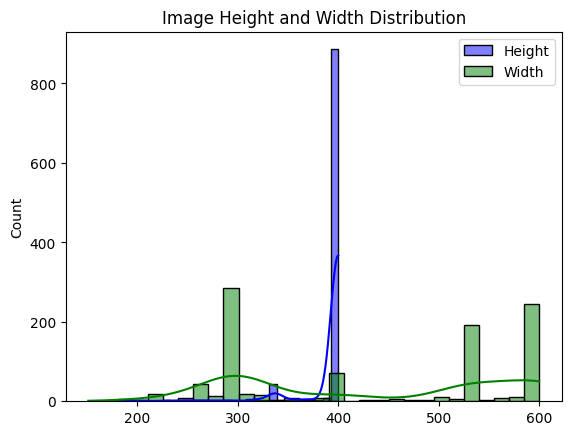

Color Channels (should mostly be 3): (array([3]), array([999]))


In [97]:
# Show image shape distribution
image_shape_analysis(df, img_dir=photos_dir)

## Text Analysis on Caption

In [98]:
# Function to analyze captions
def analyze_captions(df):
    caption_lengths = df['caption'].apply(lambda x: len(str(x).split()))
    print("Caption Word Count Summary:")
    print(caption_lengths.describe())
    
    sns.histplot(caption_lengths, bins=50, kde=True)
    plt.title("Caption Length Distribution")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()

Caption Word Count Summary:
count    8390.000000
mean        2.425626
std         4.044971
min         0.000000
25%         0.000000
50%         0.000000
75%         3.000000
max        31.000000
Name: caption, dtype: float64


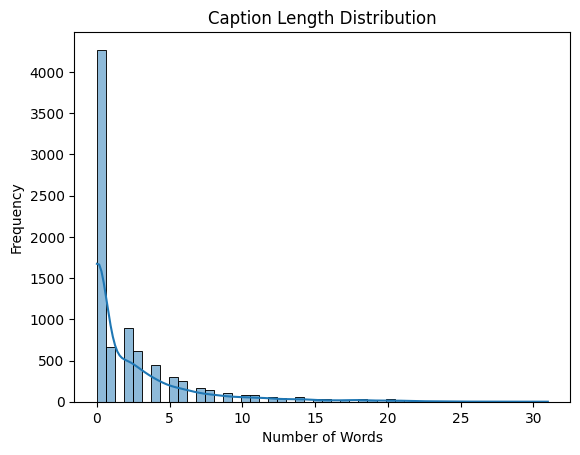

In [99]:
# Show analyzed captions
analyze_captions(df)

In [ ]:
# Get image path
df['img_path'] = df['photo_id'].apply(lambda x: os.path.join(photos_dir, f"{x}.jpg"))

In [ ]:
#  Check for image file existence
df['exists'] = df['img_path'].apply(os.path.exists)

In [ ]:
df.shape

(8390, 19)

In [ ]:
# Drop rows without image files
df = df[df['exists']].drop(columns=['exists']).reset_index(drop=True)

In [ ]:
# Check info of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8390 entries, 0 to 8389
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   photo_id      8390 non-null   object 
 1   business_id   8390 non-null   object 
 2   caption       8390 non-null   object 
 3   label         8390 non-null   object 
 4   name          8390 non-null   object 
 5   address       8390 non-null   object 
 6   city          8390 non-null   object 
 7   state         8390 non-null   object 
 8   postal_code   8390 non-null   object 
 9   latitude      8390 non-null   float64
 10  longitude     8390 non-null   float64
 11  stars         8390 non-null   float64
 12  review_count  8390 non-null   int64  
 13  is_open       8390 non-null   int64  
 14  attributes    8365 non-null   object 
 15  categories    8390 non-null   object 
 16  hours         8163 non-null   object 
 17  img_path      8390 non-null   object 
dtypes: float64(3), int64(2), obj

## Check for Corrupted images

In [ ]:
# Function to check for corrupted images
def is_corrupted(photo_id, img_dir):
    img_path = os.path.join(img_dir, f"{photo_id}.jpg")
    try:
        img = Image.open(img_path)
        img.verify()
        return None  # Not corrupted
    except:
        return photo_id  # Corrupted

def check_corrupted_images(df, img_dir='train_photos', max_workers=16):
    corrupted = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(is_corrupted, pid, img_dir) for pid in df['photo_id']]

        for future in as_completed(futures):
            result = future.result()
            if result:
                corrupted.append(result)

    print(f" Finished checking. Total Corrupted Images: {len(corrupted)}")
    return corrupted

In [ ]:
# Show corrupted images
corrupted_ids = check_corrupted_images(df, img_dir=photos_dir)

 Finished checking. Total Corrupted Images: 6


In [ ]:
# Remove those rows from the DataFrame
initial_len = len(df)
df_cleaned = df[~df['photo_id'].isin(corrupted_ids)].reset_index(drop=True)

# Print the result
print(f" Cleaned DataFrame: {len(df_cleaned)} rows remaining (removed {initial_len - len(df_cleaned)} corrupted images)")

 Cleaned DataFrame: 8384 rows remaining (removed 6 corrupted images)


In [ ]:
df = df_cleaned

In [ ]:
df.to_csv('cleaned_photos_df.csv')

## Metadata Preprocessing

In [ ]:
# Selected metadata columns
selected_columns = [
    'photo_id', 'business_id', 'label', 'img_path',
    'stars', 'review_count', 'is_open',
    'latitude', 'longitude'
]

In [ ]:
# Keep only the selected metadata columns
df = df[selected_columns].copy()

print(" Filtered DataFrame shape:", df.shape)

 Filtered DataFrame shape: (8384, 9)


In [ ]:
# Standardization function
def preprocess_metadata(df, scaler=None):
    df = df[['stars', 'review_count', 'is_open', 'latitude', 'longitude']].copy()
    if scaler is None:
        scaler = StandardScaler()
        return scaler.fit_transform(df), scaler
    else:
        return scaler.transform(df), scaler

### Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label Encoder Function
def encode_labels(df, label_col='label'):
    encoder = LabelEncoder()
    df['label_encoded'] = encoder.fit_transform(df[label_col])
    return df, encoder

In [ ]:
df, label_encoder = encode_labels(df, label_col='label')

# print df
print(df[['label', 'label_encoded']].head())

   label  label_encoded
0  drink              0
1  drink              0
2  drink              0
3  drink              0
4  drink              0


# Image Processing

In [ ]:
# 1. Image Preprocessing
def preprocess_image(img_path, model_type='vgg', target_size=(224, 224)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = cv2.GaussianBlur(img, (5, 5), 0)

    img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
    img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

    img = np.clip(img, 30, 220)

    if model_type == 'vgg':
        img = vgg_preprocess(img)
    elif model_type == 'effnet':
        img = effnet_preprocess(img)

    return img

In [ ]:
# 2. Augmentation Function
def get_augmenter():
    return ImageDataGenerator(
        rotation_range=20,
        zoom_range=0.15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        horizontal_flip=True,
        fill_mode="nearest"
    )

In [ ]:
# 3. Handling Train/Test Splits
def prepare_train_test(df, model_type='vgg'):
    X_img_paths = df['img_path'].values
    y = df['label_encoded'].values
    X_train_img_paths, X_test_img_paths, y_train, y_test = train_test_split(
        X_img_paths, y, stratify=y, test_size=0.2, random_state=42)

    # Preprocess Images
    X_train_imgs = np.array([preprocess_image(p, model_type=model_type) for p in X_train_img_paths])
    X_test_imgs = np.array([preprocess_image(p, model_type=model_type) for p in X_test_img_paths])

    # Preprocess Metadata with shared scaler
    train_df = df[df['img_path'].isin(X_train_img_paths)]
    test_df = df[df['img_path'].isin(X_test_img_paths)]

    X_train_meta, scaler = preprocess_metadata(train_df)
    X_test_meta, _ = preprocess_metadata(test_df, scaler)

    return X_train_imgs, X_test_imgs, X_train_meta, X_test_meta, y_train, y_test

### Train_Test Split

In [ ]:
# Run train-test preparation for VGG Model
X_train_imgs_vgg, X_test_imgs_vgg, X_train_meta_vgg, X_test_meta_vgg, y_train_vgg, y_test_vgg = prepare_train_test(df, model_type='vgg')

# Print shapes
print("X_train_imgs shape:", X_train_imgs_vgg.shape)
print("X_test_imgs shape:", X_test_imgs_vgg.shape)
print("X_train_meta shape:", X_train_meta_vgg.shape)
print("X_test_meta shape:", X_test_meta_vgg.shape)
print("y_train shape:", y_train_vgg.shape)
print("y_test shape:", y_test_vgg.shape)

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


X_train_imgs shape: (6707, 224, 224, 3)
X_test_imgs shape: (1677, 224, 224, 3)
X_train_meta shape: (6707, 5)
X_test_meta shape: (1677, 5)
y_train shape: (6707,)
y_test shape: (1677,)


In [ ]:
# Run train-test preparation for EfficientNet Model
X_train_imgs_effnet, X_test_imgs_effnet, X_train_meta_effnet, X_test_meta_effnet, y_train_effnet, y_test_effnet = prepare_train_test(df, model_type='effnet')

# Print shapes
print("X_train_imgs shape:", X_train_imgs_effnet.shape)
print("X_test_imgs shape:", X_test_imgs_effnet.shape)
print("X_train_meta shape:", X_train_meta_effnet.shape)
print("X_test_meta shape:", X_test_meta_effnet.shape)
print("y_train shape:", y_train_effnet.shape)
print("y_test shape:", y_test_effnet.shape)

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


X_train_imgs shape: (6707, 224, 224, 3)
X_test_imgs shape: (1677, 224, 224, 3)
X_train_meta shape: (6707, 5)
X_test_meta shape: (1677, 5)
y_train shape: (6707,)
y_test shape: (1677,)




# Image Processing and Metadata Summary



## Data Loading and Initial Exploration

- Loaded `photos.json` and `business.json` into separate DataFrames.

- The `photos_df` contained 200,100 entries with 4 key columns:

  - `photo_id`, `business_id`, `caption`, and `label`.

- Found 5 unique labels: **inside**, **outside**, **drink**, **food**, and **menu**.



## Photo Label Distribution (Before Balancing)

| Label   | Count   |
|---------|---------|
| food    | 108,152 |
| inside  | 56,031  |
| outside | 18,569  |
| drink   | 15,670  |
| menu    | 1,678   |



- Identified a **class imbalance** in the photo labels.



## Data Balancing

- Balanced the dataset by **sampling 1,678 examples** from each label to match the minority class (`menu`).

- Final photo dataset contained **8,390 samples**.



## Merging Business Metadata

- Merged `photos_df` with `business_df` using `business_id` to append metadata.

- Resulting DataFrame had **17 columns**, including location, ratings, categories, etc.

- Added a new column, `img_path`, with full paths to image files.



## DataFrame Summary After Merging

- Total entries: **8,390**

- Included key metadata: `latitude`, `longitude`, `stars`, `review_count`, `is_open`, among others.

- Some fields like `caption` and `attributes` had missing values; `caption` was deemed unhelpful for modeling due to skewed distribution and sparsity.



## Cleaning and Preparation

- Found and dropped **6 corrupted image files**.

- Focused on non-null and useful metadata features:

  - `photo_id`, `business_id`, `label`, `latitude`, `longitude`, `stars`, `review_count`, `is_open`, and `img_path`.

- Applied **label encoding** to the labels (`food`, `inside`, etc.) converting them into numeric format.



## Metadata and Image Preprocessing



### Image Characteristics

- Examined image dimensions: heights were more consistent (mode ~900px) while widths showed a multi-modal distribution.

- Noted that image sizes varied widely and preprocessing would need to account for this.



### Metadata Processing

- Selected non-null and relevant numeric features for downstream modeling.

- Ensured consistency across training and test splits by applying the same scaling during preprocessing.



## Final Train-Test Dataset Statistics



### For VGG and EfficientNet Models

- **Training set**: 6,707 images and associated metadata.

- **Test set**: 1,677 images and associated metadata.

- Image dimensions standardized to **(224, 224, 3)**.

- Metadata features were **scaled** and limited to 5 selected columns.

- Labels encoded and stratified for balanced training/testing.



## Conclusion

- Created a clean, **balanced multimodal dataset** combining Yelp photo labels and business metadata.

- Implemented robust **image preprocessing**, including resizing, denoising, histogram equalization, and clipping.

- Ensured compatibility with **deep learning pipelines**, enabling effective modeling with VGG and EfficientNet architectures.

### Transfer Learning with Pretrained VGG Network as Base - Obianuju

In [ ]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# Parameters
IMG_SIZE = (224, 224) #VGG-16 default input size
BATCH_SIZE = 32
NUM_CLASSES = 5
LEARNING_RATE = 0.0001
EPOCHS = 10

In [ ]:
# Create data generators
def create_datagen():
    return ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'

    )

train_datagen = create_datagen()
val_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Create VGG16 base model
def create_vgg_model(metadata_dim, fine_tune=False):
    # Image input and VGG16 base
    img_input = Input(shape=(*IMG_SIZE, 3))
    base_model = VGG16(weights='imagenet', include_top=False, input_tensor=img_input)

    # Partition into featurizers and classifiers
    # Keep all convolutional blocks as featurizers
    # Replace original classifier (top layers) with our custom classifier

    # Initially freeze convolutional layers
    base_model.trainable = not fine_tune

    # Image feature extraction
    x = Flatten()(base_model.output)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)

    # Metadata input
    meta_input = Input(shape=(metadata_dim,))

    # Combine features
    combined = Concatenate()([x, meta_input])
    combined = Dense(256, activation='relu', name='fc2')(combined)
    combined = Dropout(0.3, name='dropout2')(combined)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(combined)
    
    model = Model(inputs=[img_input, meta_input], outputs=outputs)

    return model

In [ ]:
# Train with frozen base
model = create_vgg_model(metadata_dim=5 , fine_tune=False)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_9[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 27,694,149 (105.64 MB)

 Trainable params: 27,694,149 (105.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Time the model training
import time
start_time = time.time()


# Fit the model
history = model.fit(
    x=[X_train_imgs_vgg, X_train_meta_vgg],
    y=y_train_vgg,
    # validation_data=([X_test_imgs_vgg, X_test_meta_vgg], y_test_vgg),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE, 
    verbose = 1
)

training_time = time.time() - start_time
print(f'Training time: {training_time/60 :.2f} minutes')

Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1987s 9s/step - accuracy: 0.3091 - loss: 2.0603
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2068s 10s/step - accuracy: 0.6366 - loss: 0.9204
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2095s 10s/step - accuracy: 0.7996 - loss: 0.5613
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1918s 9s/step - accuracy: 0.8558 - loss: 0.4279
Epoch 5/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1994s 9s/step - accuracy: 0.8850 - loss: 0.3230
Epoch 6/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1990s 9s/step - accuracy: 0.9085 - loss: 0.2644
Epoch 7/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1897s 9s/step - accuracy: 0.9381 - loss: 0.1725
Epoch 8/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1958s 9s/step - accuracy: 0.9229 - loss: 0.2177
Epoch 9/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1948s 9s/step - accuracy: 0.9559 - loss: 0.1289
Epoch 10/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2258s 11s/step - accuracy: 0.9660 - loss: 0.1121
Training time: 335.51 minutes


In [ ]:
# Save the model to .h5 format
model.save('vgg16_yelp_model.h5')

In [118]:
# Check the training accuracy
train_class, train_accuracy = model.evaluate(
    x=[X_train_imgs_vgg, X_train_meta_vgg],
    y=y_train_vgg,
    verbose=1
)

210/210 ━━━━━━━━━━━━━━━━━━━━ 669s 3s/step - accuracy: 0.9623 - loss: 0.1271


In [ ]:
# Check validation accuracy
from sklearn.metrics import accuracy_score
test_class, test_accuracy = model.evaluate(
    x=[X_test_imgs_vgg, X_test_meta_vgg],
    y=y_test_vgg,
    verbose=1
)

print(f"Test Accuracy: {test_accuracy:.4f}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - accuracy: 0.8474 - loss: 0.5525
Test Accuracy: 0.8468


In [ ]:
# Make predictions on the test set
y_pred_vgg = model.predict([X_test_imgs_vgg, X_test_meta_vgg])

# Threshold predictions
y_pred_binary_vgg = (y_pred_vgg > 0.5).astype(int)


53/53 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step


In [ ]:
print(y_pred_vgg)

[[8.4908271e-01 1.4154064e-02 9.5575072e-02 6.1102677e-03 3.5077814e-02]
 [8.7449680e-06 9.9999106e-01 1.7913176e-07 3.0273895e-08 2.0374690e-08]
 [9.9669498e-01 5.1069824e-04 5.9401197e-04 1.2107418e-04 2.0792845e-03]
 ...
 [4.0588281e-03 9.9556357e-01 2.8238783e-04 5.4710708e-05 4.0463096e-05]
 [3.7904799e-02 9.4197355e-03 8.6526501e-01 7.2684862e-02 1.4725581e-02]
 [7.6378047e-01 2.2909322e-01 5.6336708e-03 9.6395402e-04 5.2863586e-04]]


In [ ]:
print(y_pred_binary_vgg)

[[1 0 0 0 0]
 [0 1 0 0 0]
 [1 0 0 0 0]
 ...
 [0 1 0 0 0]
 [0 0 1 0 0]
 [1 0 0 0 0]]


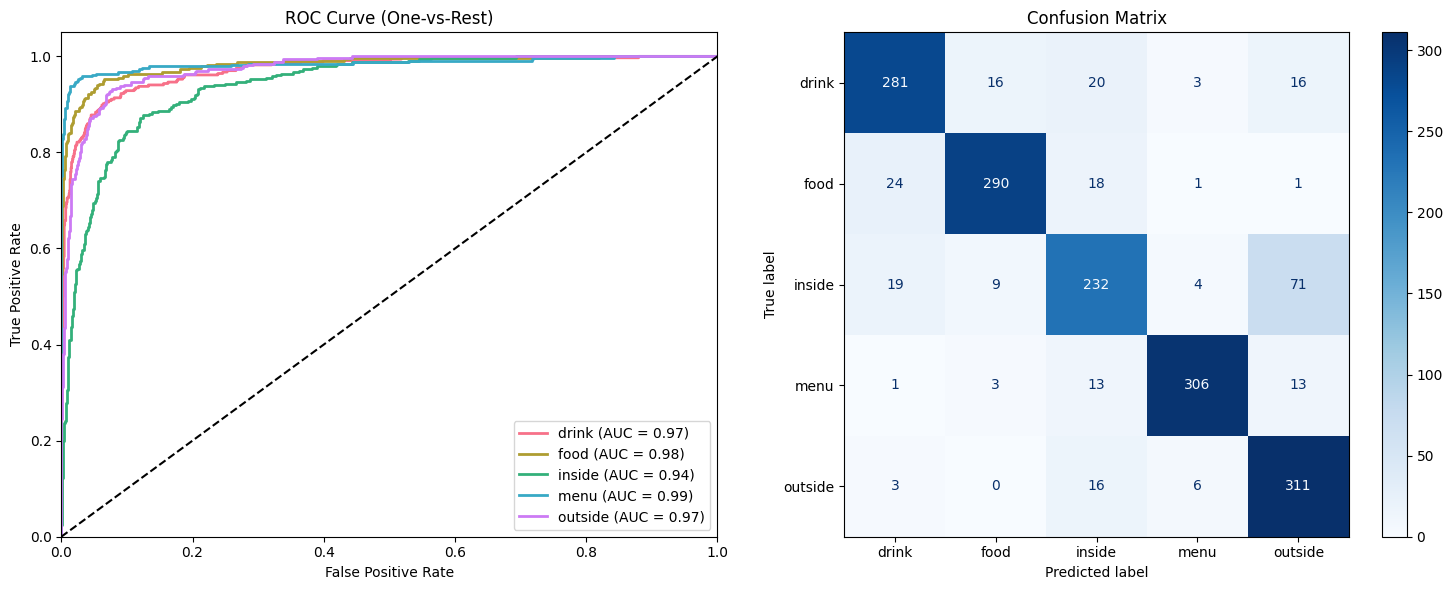

In [117]:
# Metrics visualization
def plot_metrics(y_true, y_pred, class_names):
    plt.figure(figsize=(15,6))
    from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
    from sklearn.preprocessing import label_binarize

    # ROC Curve
    plt.subplot(1,2,1)
    y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    colors = sns.color_palette("husl", len(class_names))


    for i, color in zip(range(len(class_names)), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_pred[:,i])
        roc_auc= auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
       
    plt.plot([0,1],[0,1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (One-vs-Rest)')
    plt.legend(loc='lower right')

    # Confusion Matrix
    plt.subplot(1,2,2)
    cm = confusion_matrix(y_true, np.argmax(y_pred, axis=1))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=class_names)
    disp.plot(cmap='Blues', ax=plt.gca())
    plt.title('Confusion Matrix')


    plt.tight_layout()
    plt.show()

plot_metrics(y_test_vgg, y_pred_vgg, label_encoder.classes_)

### Dealing With Overfitting - First Round of Tuning: Structural Changes

In [123]:
# Enhanced data augmentation
def train_augmenter():
    return ImageDataGenerator(
        rescale=1./255,
        rotation_range=30,
        shear_range=0.25,
        zoom_range=0.25,
        width_shift_range=0.25,
        height_shift_range=0.25,
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=[0.8, 1.2],
        fill_mode="nearest"
    )

In [124]:
# Create VGG16 base model - with regularization
def create_vgg_model(metadata_dim, fine_tune=False):
    # Batch Normalization import
    from tensorflow.keras.layers import BatchNormalization

    # Image input and VGG16 base
    img_input = Input(shape=(*IMG_SIZE, 3))
    base_model = VGG16(weights='imagenet', include_top=False, input_tensor=img_input)

    # Partition into featurizers and classifiers
    # Keep all convolutional blocks as featurizers
    # Replace original classifier (top layers) with our custom classifier

    # Initially freeze convolutional layers
    base_model.trainable = not fine_tune

    # Image feature extraction
    x = Flatten()(base_model.output)
    x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x) # Reduced from 512
    x = BatchNormalization()(x) # Added Batch Normalization
    x = Dropout(0.7)(x) #Increated dropout rate

    # Metadata input
    meta_input = Input(shape=(metadata_dim,))

    # Combine features
    combined = Concatenate()([x, meta_input])
    combined = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01), name='fc2')(combined)
    combined = BatchNormalization(name='bn2')(combined) # Added Batch Normalization
    combined = Dropout(0.6, name='dropout2')(combined)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(combined)
    
    model = Model(inputs=[img_input, meta_input], outputs=outputs)

    return model

In [125]:
# Train with frozen base
model = create_vgg_model(metadata_dim=5 , fine_tune=False)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_11[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 21,173,189 (80.77 MB)

 Trainable params: 21,172,421 (80.77 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
# Time the model training of the tuned model
import time
start_time = time.time()


# Fit the model
history = model.fit(
    x=[X_train_imgs_vgg, X_train_meta_vgg],
    y=y_train_vgg,
    # validation_data=([X_test_imgs_vgg, X_test_meta_vgg], y_test_vgg),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE, 
    verbose = 1
)

training_time = time.time() - start_time
print(f'Training time: {training_time/60 :.2f} minutes')

Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2274s 11s/step - accuracy: 0.2758 - loss: 8.3224
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 3438s 16s/step - accuracy: 0.3165 - loss: 5.8862
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2959s 14s/step - accuracy: 0.3740 - loss: 4.8560
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2273s 11s/step - accuracy: 0.4277 - loss: 4.1717
Epoch 5/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 5114s 24s/step - accuracy: 0.4440 - loss: 3.8331
Epoch 6/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 4667s 22s/step - accuracy: 0.4512 - loss: 3.4410
Epoch 7/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2695s 13s/step - accuracy: 0.5199 - loss: 3.0645
Epoch 8/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 6108s 29s/step - accuracy: 0.5403 - loss: 2.8306
Epoch 9/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2685s 13s/step - accuracy: 0.5822 - loss: 2.5735
Epoch 10/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2760s 13s/step - accuracy: 0.6361 - loss: 2.3160
Training time: 583.17 minutes


In [ ]:
# Check the training accuracy of the tuned model
train_class, train_accuracy = model.evaluate(
    x=[X_train_imgs_vgg, X_train_meta_vgg],
    y=y_train_vgg,
    verbose=1
)

210/210 ━━━━━━━━━━━━━━━━━━━━ 581s 3s/step - accuracy: 0.6830 - loss: 2.1265


In [128]:
# Check validation accuracy
from sklearn.metrics import accuracy_score
test_class, test_accuracy = model.evaluate(
    x=[X_test_imgs_vgg, X_test_meta_vgg],
    y=y_test_vgg,
    verbose=1
)

53/53 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.6481 - loss: 2.1777


In [ ]:
# Make predictions on the test set for the 
y_pred_vgg = model.predict([X_test_imgs_vgg, X_test_meta_vgg])

# Threshold predictions
y_pred_binary_vgg = (y_pred_vgg > 0.5).astype(int)

53/53 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step


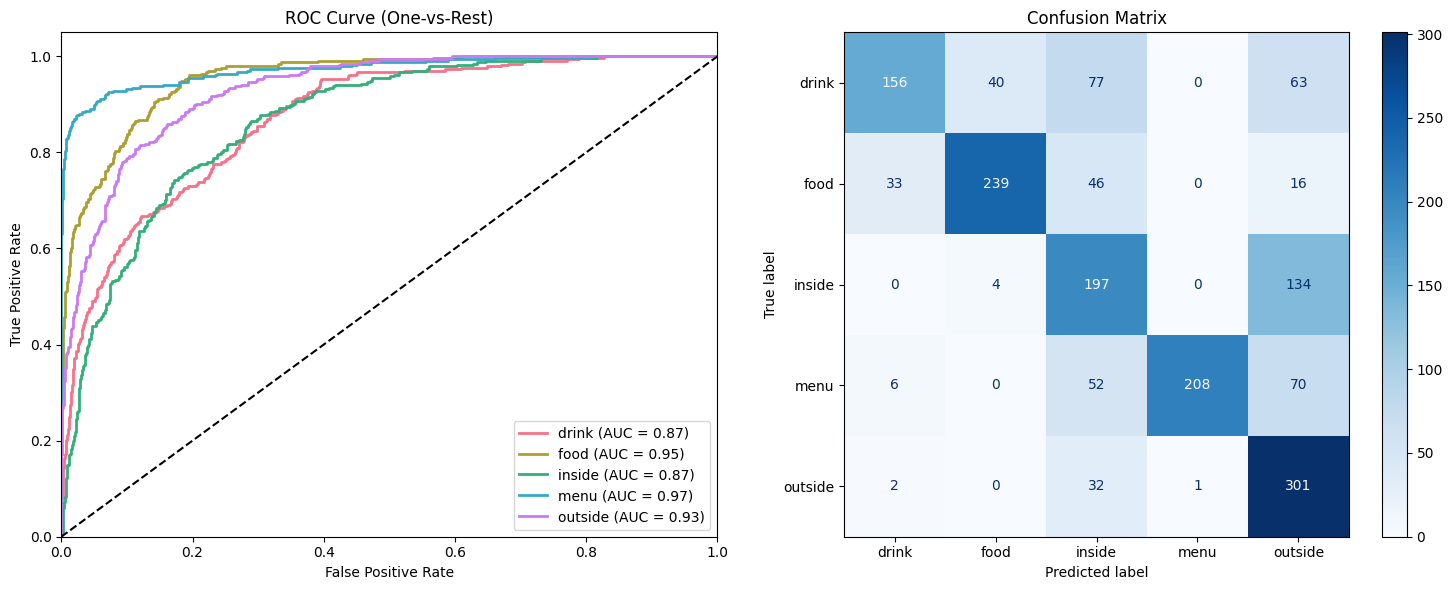

In [131]:
# Metrics visualization of the tuned model
def plot_metrics(y_true, y_pred, class_names):
    plt.figure(figsize=(15,6))
    from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
    from sklearn.preprocessing import label_binarize

    # ROC Curve
    plt.subplot(1,2,1)
    y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    colors = sns.color_palette("husl", len(class_names))


    for i, color in zip(range(len(class_names)), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_pred[:,i])
        roc_auc= auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
       
    plt.plot([0,1],[0,1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (One-vs-Rest)')
    plt.legend(loc='lower right')

    # Confusion Matrix
    plt.subplot(1,2,2)
    cm = confusion_matrix(y_true, np.argmax(y_pred, axis=1))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=class_names)
    disp.plot(cmap='Blues', ax=plt.gca())
    plt.title('Confusion Matrix')


    plt.tight_layout()
    plt.show()

plot_metrics(y_test_vgg, y_pred_vgg, label_encoder.classes_)

 #### The model behaved poorer with the first tuning - especialy with drink, menu and inside labels.
 - Regularization was too aggressive
 - High losses >2.0 indicates that the model was not converging well.

### 2nd Round of Tuning With Milder Regularization and Gradient Clipping

In [135]:
# Create VGG16 base model - with milder regularization
def create_vgg_model(metadata_dim, fine_tune=False):
    # Batch Normalization import
    from tensorflow.keras.layers import BatchNormalization

    # Image input and VGG16 base
    img_input = Input(shape=(*IMG_SIZE, 3))
    base_model = VGG16(weights='imagenet', include_top=False, input_tensor=img_input)

    # Partition into featurizers and classifiers
    # Keep all convolutional blocks as featurizers
    # Replace original classifier (top layers) with our custom classifier

    # Initially freeze convolutional layers
    base_model.trainable = not fine_tune

    # Image feature extraction
    x = Flatten()(base_model.output)
    x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x) # Reduced from 0.01 to 0.001
    x = BatchNormalization()(x) 
    x = Dropout(0.4)(x) #Reduced dropout rate from 0.7 to 0.4

    # Metadata input
    meta_input = Input(shape=(metadata_dim,))

    # Combine features
    combined = Concatenate()([x, meta_input])
    combined = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), name='fc2')(combined)
    combined = BatchNormalization(name='bn2')(combined)
    combined = Dropout(0.3, name='dropout2')(combined) # Reduced dropout rate from 0.6 t0 0.3
    outputs = Dense(NUM_CLASSES, activation='softmax', name='output')(combined)
    
    model = Model(inputs=[img_input, meta_input], outputs=outputs)

    return model

In [136]:
# Train with frozen base
model2 = create_vgg_model(metadata_dim=5 , fine_tune=False)

# Compile with optimizer
optimizer = Adam(
    learning_rate = 1e-4,
    clipnorm=1.0, #Gradient clipping to prevent exploding gradients
    beta_1=0.9, #Momemtum parameters
    beta_2=0.999
)

# Compile the model
model2.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_15[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 21,173,189 (80.77 MB)

 Trainable params: 21,172,421 (80.77 MB)

 Non-trainable params: 768 (3.00 KB)

In [141]:
# Time the model training of the 2nd tuning
 
import time
start_time = time.time()

# Include EalryStopping and ReduceLROnPlateau callbacks
# from tensorflow.keras.callbacks import callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stopping = EarlyStopping(
    monitor='val_loss', # Stop training when validation loss stops improving
    patience=8, # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity
    min_delta=0.001 # Minimum change in the monitored quantity to qualify as an improvement
)

# Fit the model
history2 = model2.fit(
    x=[X_train_imgs_vgg, X_train_meta_vgg],
    y=y_train_vgg,
    # validation_data=([X_test_imgs_vgg, X_test_meta_vgg], y_test_vgg),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE, 
    verbose = 1,
    callbacks=[early_stopping, ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)]
)

training_time = time.time() - start_time
print(f'Training time for 2nd tuning: {training_time/60 :.2f} minutes')

Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2583s 12s/step - accuracy: 0.5416 - loss: 1.9766 - learning_rate: 1.0000e-04
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 4223s 20s/step - accuracy: 0.7763 - loss: 1.2168 - learning_rate: 1.0000e-04
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2510s 12s/step - accuracy: 0.8263 - loss: 1.0030 - learning_rate: 1.0000e-04
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1954s 9s/step - accuracy: 0.8607 - loss: 0.8337 - learning_rate: 1.0000e-04
Epoch 5/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1967s 9s/step - accuracy: 0.8850 - loss: 0.6980 - learning_rate: 1.0000e-04
Epoch 6/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2179s 10s/step - accuracy: 0.9062 - loss: 0.5974 - learning_rate: 1.0000e-04
Epoch 7/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2224s 11s/step - accuracy: 0.9336 - loss: 0.4885 - learning_rate: 1.0000e-04
Epoch 8/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2946s 14s/step - accuracy: 0.9496 - loss: 0.4141 - learning_rate: 1.0000e-04
Epoch 9/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2567s 12s/step - accuracy:

In [145]:
# Check the training accuracy from 2nd tuning
train_class, train_accuracy = model2.evaluate(
    x=[X_train_imgs_vgg, X_train_meta_vgg],
    y=y_train_vgg,
    verbose=1
)

210/210 ━━━━━━━━━━━━━━━━━━━━ 593s 3s/step - accuracy: 0.9870 - loss: 0.2398


In [146]:
# Check validation accuracy from 2nd tuning
from sklearn.metrics import accuracy_score
test_class, test_accuracy = model2.evaluate(
    x=[X_test_imgs_vgg, X_test_meta_vgg],
    y=y_test_vgg,
    verbose=1
)

53/53 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.8580 - loss: 0.7592


In [147]:
# Make predictions on the test set
y_pred_vgg = model2.predict([X_test_imgs_vgg, X_test_meta_vgg])

# Threshold predictions
y_pred_binary_vgg = (y_pred_vgg > 0.5).astype(int)

53/53 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step


In [143]:
# Save the model to pickle format
import pickle
with open('vgg16_yelp_model2.pkl', 'wb') as f:
    pickle.dump(model2, f)

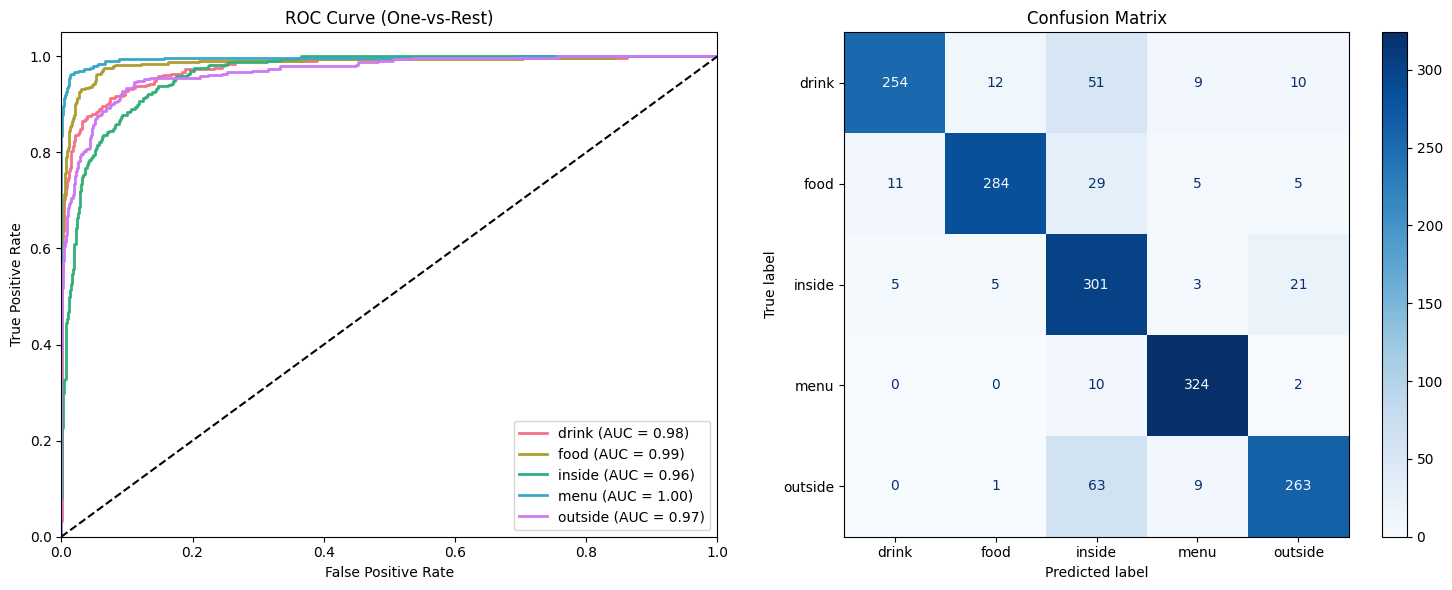

In [148]:
# Metrics visualization
def plot_metrics(y_true, y_pred, class_names):
    plt.figure(figsize=(15,6))
    from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
    from sklearn.preprocessing import label_binarize

    # ROC Curve
    plt.subplot(1,2,1)
    y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    colors = sns.color_palette("husl", len(class_names))


    for i, color in zip(range(len(class_names)), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_pred[:,i])
        roc_auc= auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
       
    plt.plot([0,1],[0,1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (One-vs-Rest)')
    plt.legend(loc='lower right')

    # Confusion Matrix
    plt.subplot(1,2,2)
    cm = confusion_matrix(y_true, np.argmax(y_pred, axis=1))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=class_names)
    disp.plot(cmap='Blues', ax=plt.gca())
    plt.title('Confusion Matrix')


    plt.tight_layout()
    plt.show()

plot_metrics(y_test_vgg, y_pred_vgg, label_encoder.classes_)

### Summary of Model Performance After Tuning
#### Key Metrics
- Training accuracy: 98.7% (Loss: 0.2398)
- Test Accuracy: 85.8% (Loss: 0.7592)
- AUC Scores (Excellent):
    - Menu: 1:00
    - Food: 0.99
    - Drink: 0.98
    - Outside: 0.97
    - Inside: 0.96
#### Confusion Matrix Insights
- Best Class: "Menu" (324 correct, with minimal false positives).
- Most confused pairs:
    - Drink vs. Inside (51 misclassified as Inside)
    - Inside vs. Outside (21 misclassified as Outside)
- Most of the confusion is in comparison of the other labels to Inside

#### Diagnosis
- Overfitting: Large gap, despite regularization, between train (98.7%) and test accuracy(85.8%)
- Strong Base Performance: High AUC scores indicate excellent class separation

### Recommended Next Steps
- Data augmentation - add more variability
- Address class confusion
    - Focus on Drink vs Inside by visualizing misclassified samples to identify patterns or similar backgrounds. Then add negative samples to the training set
- Finetuning
- Per-Class metrics and error analysis